In [2]:
import pandas as pd
import re
import os
import numpy as np
from difflib import SequenceMatcher
import matplotlib.pyplot as plt


In [3]:
import time
from bs4 import BeautifulSoup     

In [4]:
import sys
from pathlib import Path

# 1. Figure out where you are
notebook_dir = Path().cwd()  

# 2. Build the path to the module folder
viz_folder = notebook_dir.parent / "06_preclin_clinic_join"

# 3. Insert it onto sys.path
sys.path.insert(0, str(viz_folder.resolve()))

# 4. Now import
from viz_data import plot_top_entities_side_by_side


In [5]:
df_path = "../06_preclin_clinic_join/data/joined_data/preclinical_metadata_mapped_annotated_20250723.csv"

In [11]:
preclinical_df_raw = pd.read_csv(df_path)

In [12]:
preclinical_df_raw = preclinical_df_raw[
    preclinical_df_raw['animal_strain'].fillna('').str.strip().str.lower() != 'no full text'
]

In [64]:
preclinical_df_raw.shape

(32762, 24)

In [66]:
preclinical_df_raw.to_csv("../09_explore_studies/preclinical_metadata_mapped_annotated_20250723_filtered.csv")

In [17]:
preclinical_df_raw

,PMID,year,journal_name,publication_type,title,Unnamed: 0,raw_disease,raw_drug,linkbert_mapped_conditions,linkbert_mapped_drugs,...,animal_sex,animal_species,animal_age_class,animal_age,rigor_blinding,rigor_randomization,rigor_welfare,assay_type,animal_strain,animal_number
0,31733940,2020.0,Neuron,"Journal Article+Research Support, Non-U.S. Gov't",Resolving and Rescuing Developmental Miswiring...,3,cognitive impairment,minocycline,cognitive impairment,minocycline,...,sex-male,mouse,adult,8-10 weeks,blinding-present,randomization-present,welfare-present,"Behavioral, Histology, Imaging, Molecular & Ce...","C57BL/6J,C57Bl6/J",10.0
1,31734290,2020.0,Neuroscience letters,"Journal Article+Research Support, Non-U.S. Gov't",Perampanel attenuates epileptiform phenotype i...,13,glioma-associated seizures|glioma-associated e...,perampanel|ampa receptor antagonist perampanel...,glioma-associated seizures|glioma-associated e...,perampanel|ampa receptor antagonist perampanel...,...,sex-not-reported,rat,adult,9-12 weeks,blinding-not-reported,randomization-present,welfare-present,Histology,"Wistar,Wister",unlabeled
9,31738372,2020.0,JAMA neurology,Journal Article+Randomized Controlled Trial+Re...,Minocycline at 2 Different Dosages vs Placebo ...,60,dementia|alzheimer disease,minocycline|minocycline hydrochloride,dementia|alzheimer disease,minocycline|minocycline,...,sex-not-reported,species-other,unlabeled,unlabeled,blinding-present,randomization-present,welfare-present,unlabeled,unlabeled,unlabeled
10,31738883,2020.0,Neuroscience,"Journal Article+Research Support, N.I.H., Extr...",Sex Differences and Estrous Influences on Oxyt...,70,obesity,oxytocin,obesity,oxytocin,...,sex-both,rat,unlabeled,unlabeled,blinding-not-reported,randomization-not-reported,welfare-present,"Histology, Molecular & Cellular",Sprague-Dawley,16.0
11,31738884,2020.0,Neuroscience,"Journal Article+Research Support, Non-U.S. Gov't",Dimethyl Fumarate Reduces Microglia Functional...,71,multiple sclerosis,dimethyl fumarate,multiple sclerosis,dimethyl fumarate,...,sex-not-reported,mouse,unlabeled,unlabeled,blinding-not-reported,randomization-not-reported,welfare-present,"Histology, Imaging, Molecular & Cellular","C56Bl6J,C57BL/6J",unlabeled
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94789,29916184,2018.0,Metabolic brain disease,"Journal Article+Research Support, N.I.H., Extr...",Antibiotics protect against EAE by increasing ...,2633,multiple sclerosis,ampicillin|neomycin|vancomycin|metronidazole,multiple sclerosis,ampicillin|neomycin|vancomycin|metronidazole,...,sex-female,mouse,adult,8-10 weeks,blinding-present,randomization-not-reported,welfare-present,"Behavioral, Histology, Molecular & Cellular, P...",C57BL/6-Tg(Scgb1a1-TFRC/OVA)1Adl/Bmed,unlabeled
94796,29163764,2017.0,Oncotarget,Journal Article,Inhibition of autoimmune Th17 cell responses b...,2657,multiple sclerosis,ketamine,multiple sclerosis,ketamine,...,sex-not-reported,mouse,"adult, young",6-10 weeks,blinding-not-reported,randomization-not-reported,welfare-present,Molecular & Cellular,C57BL/6-Tg(Scgb1a1-TFRC/OVA)1Adl/Bmed,unlabeled
94821,30385785,2018.0,Nature communications,"Journal Article+Research Support, N.I.H., Extr...",Acute microglia ablation induces neurodegenera...,2781,multiple sclerosis,minocycline|anti-ifnar1 antibody,multiple sclerosis,minocycline|anti-ifnar1 antibody,...,sex-not-reported,mouse,unlabeled,unlabeled,blinding-present,randomization-present,welfare-not-reported,"Behavioral, Histology, Molecular & Cellular, P...",C57BL/6-Tg(Scgb1a1-TFRC/OVA)1Adl/Bmed,unlabeled
94823,27573366,2016.0,Cytokine,"Journal Article+Research Support, N.I.H., Extr...",Modeling of both shared and distinct interacti...,2810,multiple sclerosis,dra1-mog-35-55|rtl1000|mif,multiple sclerosis,dra1-mog-35-55|rtl1000|mif,...,sex-not-reported,species-other,unlabeled,unlabeled,blinding-not-reported,randomization-not-reported,welfare-not-reported,Molecular & Cellular,unlabeled,unlabele

In [19]:
df = preclinical_df_raw.copy()
# 1. Tested in both sexes
df['tested_in_both_sexes'] = df['animal_sex'].apply(lambda x: 1 if x == 'sex-both' else 0)

# 2. Tested in two or more strains
df['tested_in_multiple_strains'] = df['animal_strain'].apply(lambda x: 1 if isinstance(x, str) and ',' in x else 0)

# 3. Tested in two or more species
df['tested_in_multiple_species'] = df['animal_species'].apply(lambda x: 1 if isinstance(x, str) and ',' in x else 0)

# 4. Tested with at least two outcomes
df['tested_with_multiple_outcomes'] = df['assay_type'].apply(lambda x: 1 if isinstance(x, str) and ',' in x else 0)

# 5. Rigor criteria mapping
rigor_cols = ['rigor_blinding', 'rigor_randomization', 'rigor_welfare']
for col in rigor_cols:
    df[col + '_binary'] = df[col].apply(lambda x: 1 if isinstance(x, str) and 'present' in x else 0)

In [21]:
df.head()

,PMID,year,journal_name,publication_type,title,Unnamed: 0,raw_disease,raw_drug,linkbert_mapped_conditions,linkbert_mapped_drugs,...,assay_type,animal_strain,animal_number,tested_in_both_sexes,tested_in_multiple_strains,tested_in_multiple_species,tested_with_multiple_outcomes,rigor_blinding_binary,rigor_randomization_binary,rigor_welfare_binary
0,31733940,2020.0,Neuron,"Journal Article+Research Support, Non-U.S. Gov't",Resolving and Rescuing Developmental Miswiring...,3,cognitive impairment,minocycline,cognitive impairment,minocycline,...,"Behavioral, Histology, Imaging, Molecular & Ce...","C57BL/6J,C57Bl6/J",10.0,0,1,0,1,1,1,1
1,31734290,2020.0,Neuroscience letters,"Journal Article+Research Support, Non-U.S. Gov't",Perampanel attenuates epileptiform phenotype i...,13,glioma-associated seizures|glioma-associated e...,perampanel|ampa receptor antagonist perampanel...,glioma-associated seizures|glioma-associated e...,perampanel|ampa receptor antagonist perampanel...,...,Histology,"Wistar,Wister",unlabeled,0,1,0,0,0,1,1
9,31738372,2020.0,JAMA neurology,Journal Article+Randomized Controlled Trial+Re...,Minocycline at 2 Different Dosages vs Placebo ...,60,dementia|alzheimer disease,minocycline|minocycline hydrochloride,dementia|alzheimer disease,minocycline|minocycline,...,unlabeled,unlabeled,unlabeled,0,0,0,0,1,1,1
10,31738883,2020.0,Neuroscience,"Journal Article+Research Support, N.I.H., Extr...",Sex Differences and Estrous Influences on Oxyt...,70,obesity,oxytocin,obesity,oxytocin,...,"Histology, Molecular & Cellular",Sprague-Dawley,16.0,1,0,0,1,0,0,1
11,31738884,2020.0,Neuroscience,"Journal Article+Research Support, Non-U.S. Gov't",Dimethyl Fumarate Reduces Microglia Functional...,71,multiple sclerosis,dimethyl fumarate,multiple sclerosis,dimethyl fumarate,...,"Histology, Imaging, Molecular & Cellular","C56Bl6J,C57BL/6J",unlabeled,0,1,0,1,0,0,1


In [23]:
df.columns

Index(['PMID', 'year', 'journal_name', 'publication_type', 'title',
       'Unnamed: 0', 'raw_disease', 'raw_drug', 'linkbert_mapped_conditions',
       'linkbert_mapped_drugs', 'disease', 'disease_mondo_termid', 'drug',
       'drug_umls_termid', 'animal_sex', 'animal_species', 'animal_age_class',
       'animal_age', 'rigor_blinding', 'rigor_randomization', 'rigor_welfare',
       'assay_type', 'animal_strain', 'animal_number', 'tested_in_both_sexes',
       'tested_in_multiple_strains', 'tested_in_multiple_species',
       'tested_with_multiple_outcomes', 'rigor_blinding_binary',
       'rigor_randomization_binary', 'rigor_welfare_binary'],
      dtype='object')

## Trends: values

In [50]:
def plot_counts_and_trends(df, column_with_comma_values, top_n=10, max_label_length=15):
   
    # Split comma-separated values into separate rows
    exploded_df = df.copy()
    exploded_df[column_with_comma_values] = exploded_df[column_with_comma_values].fillna('')
    exploded_df[column_with_comma_values] = exploded_df[column_with_comma_values].str.split(',')
    exploded_df = exploded_df.explode(column_with_comma_values)
    exploded_df[column_with_comma_values] = exploded_df[column_with_comma_values].str.strip()

    # Truncate long labels
    exploded_df[column_with_comma_values] = exploded_df[column_with_comma_values].apply(
        lambda x: x[:max_label_length] if len(x) > max_label_length else x
    )

    # Drop empty entries
    exploded_df = exploded_df[exploded_df[column_with_comma_values] != '']

    # Get total counts and select top N
    total_counts = exploded_df.groupby(column_with_comma_values)['PMID'].nunique()
    top_values = total_counts.sort_values(ascending=False).head(top_n).index

    # Filter for top values only
    filtered_df = exploded_df[exploded_df[column_with_comma_values].isin(top_values)]

    # Recalculate total counts for plotting
    total_counts_filtered = filtered_df.groupby(column_with_comma_values)['PMID'].nunique().sort_values(ascending=False)

    # Create trend data
    trend_data = (
        filtered_df.groupby([column_with_comma_values, 'year'])['PMID']
        .nunique()
        .reset_index()
        .pivot(index='year', columns=column_with_comma_values, values='PMID')
        .fillna(0)
    )

    # Plotting
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # Bar chart for total counts
    total_counts_filtered.plot(kind='bar', ax=axes[0])
    axes[0].set_title(f'Top {top_n} {column_with_comma_values} by Unique PMID Count')
    axes[0].set_xlabel(column_with_comma_values, fontsize=15)
    axes[0].set_ylabel('Unique PMID Count', fontsize=15)
    axes[0].tick_params(axis='x', rotation=90, labelsize=15)
    axes[0].tick_params(axis='y', labelsize=15)
    
    # Line chart for yearly trends
    trend_data.plot(ax=axes[1])
    axes[1].set_title(f'Trend Over Time for Top {top_n} {column_with_comma_values}')
    axes[1].set_xlabel('Year', fontsize=15)
    axes[1].set_ylabel('Unique PMID Count', fontsize=15)
    axes[1].tick_params(axis='x', labelsize=15)
    axes[1].tick_params(axis='y', labelsize=15)

    plt.tight_layout()
    plt.show()

In [52]:
preclinical_df = preclinical_df_raw.copy()

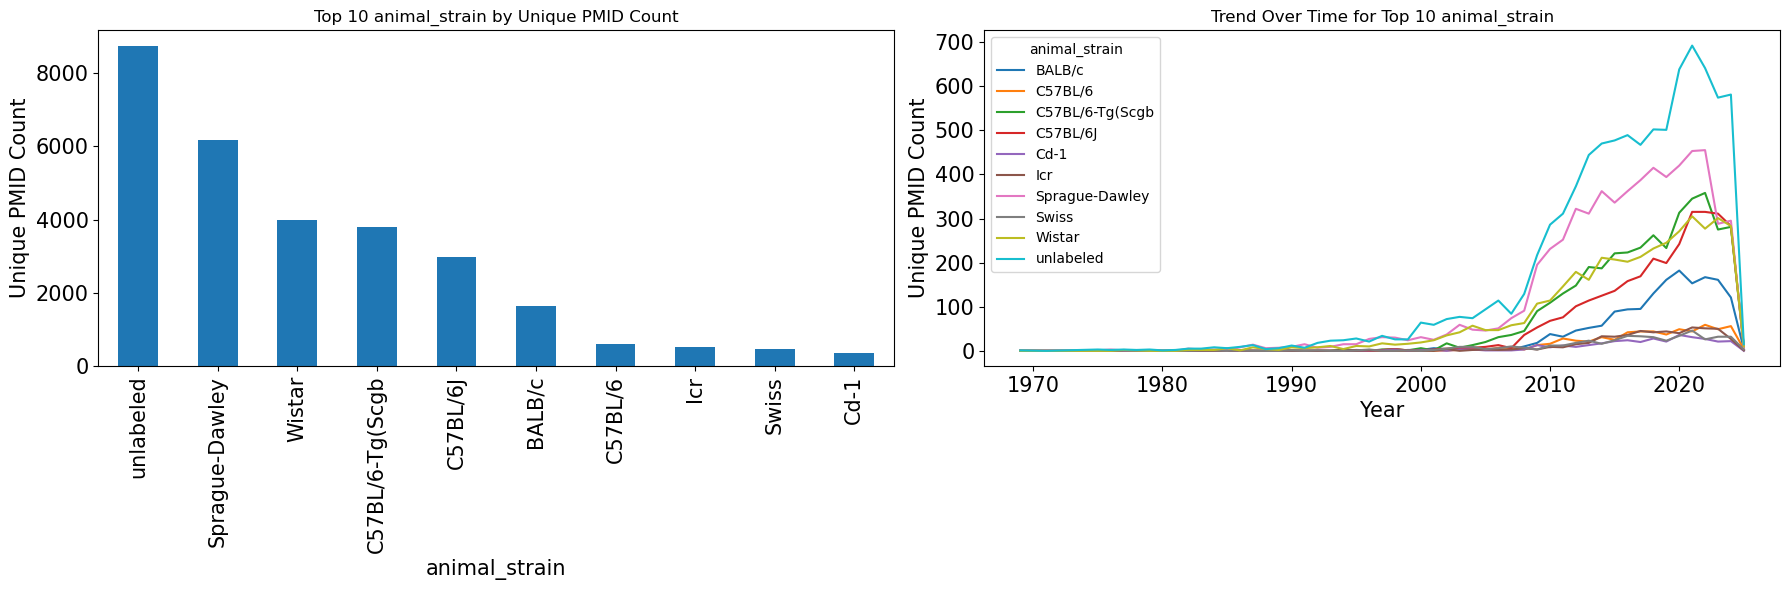

In [54]:
plot_counts_and_trends(preclinical_df, "animal_strain")

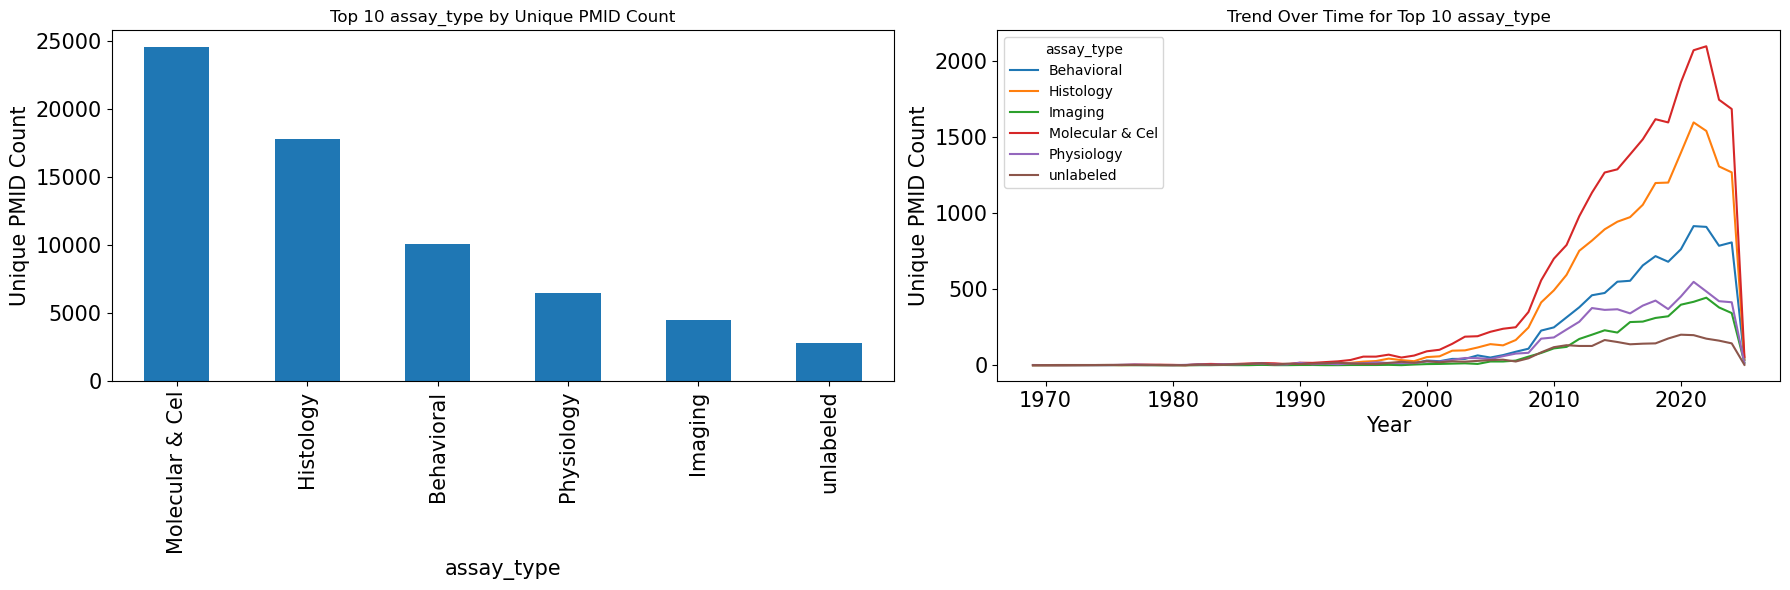

In [56]:
plot_counts_and_trends(preclinical_df, "assay_type")

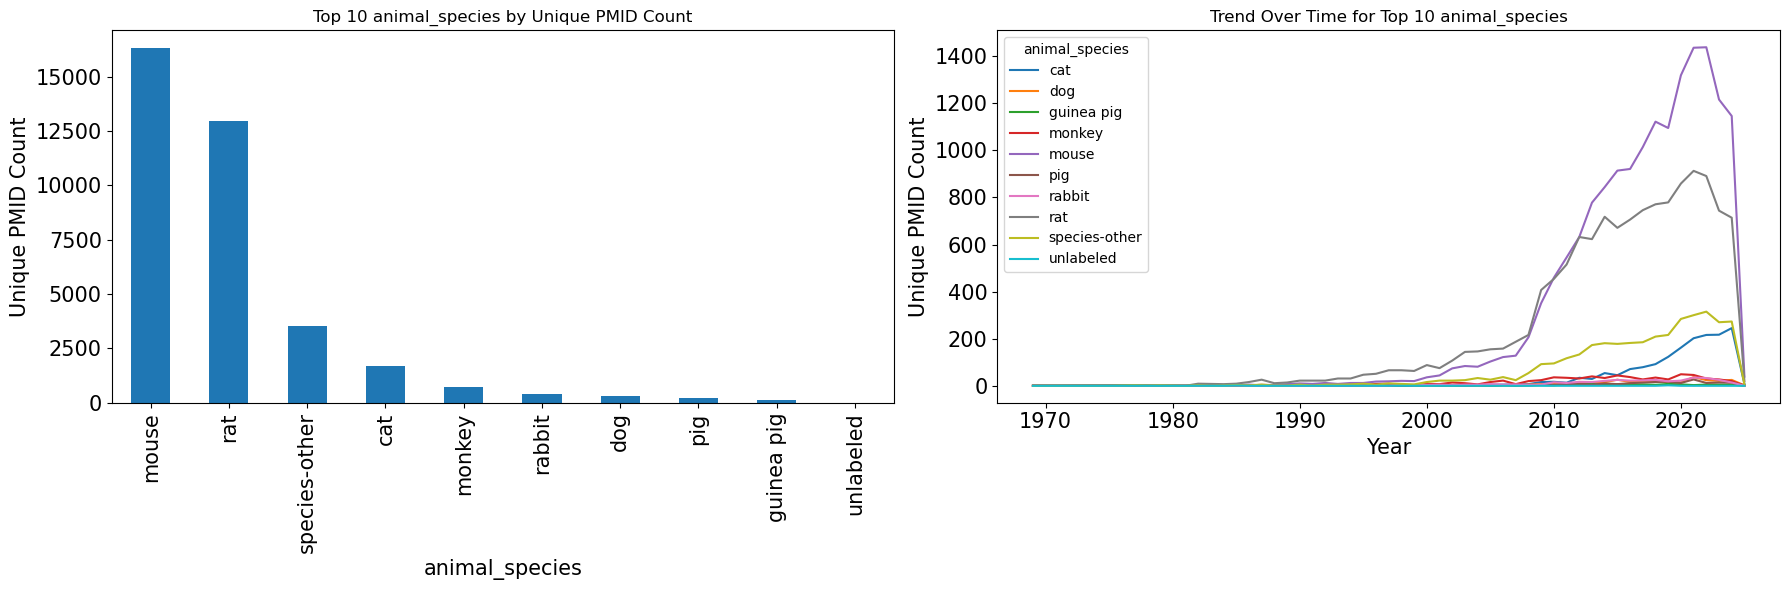

In [58]:
plot_counts_and_trends(preclinical_df, "animal_species")

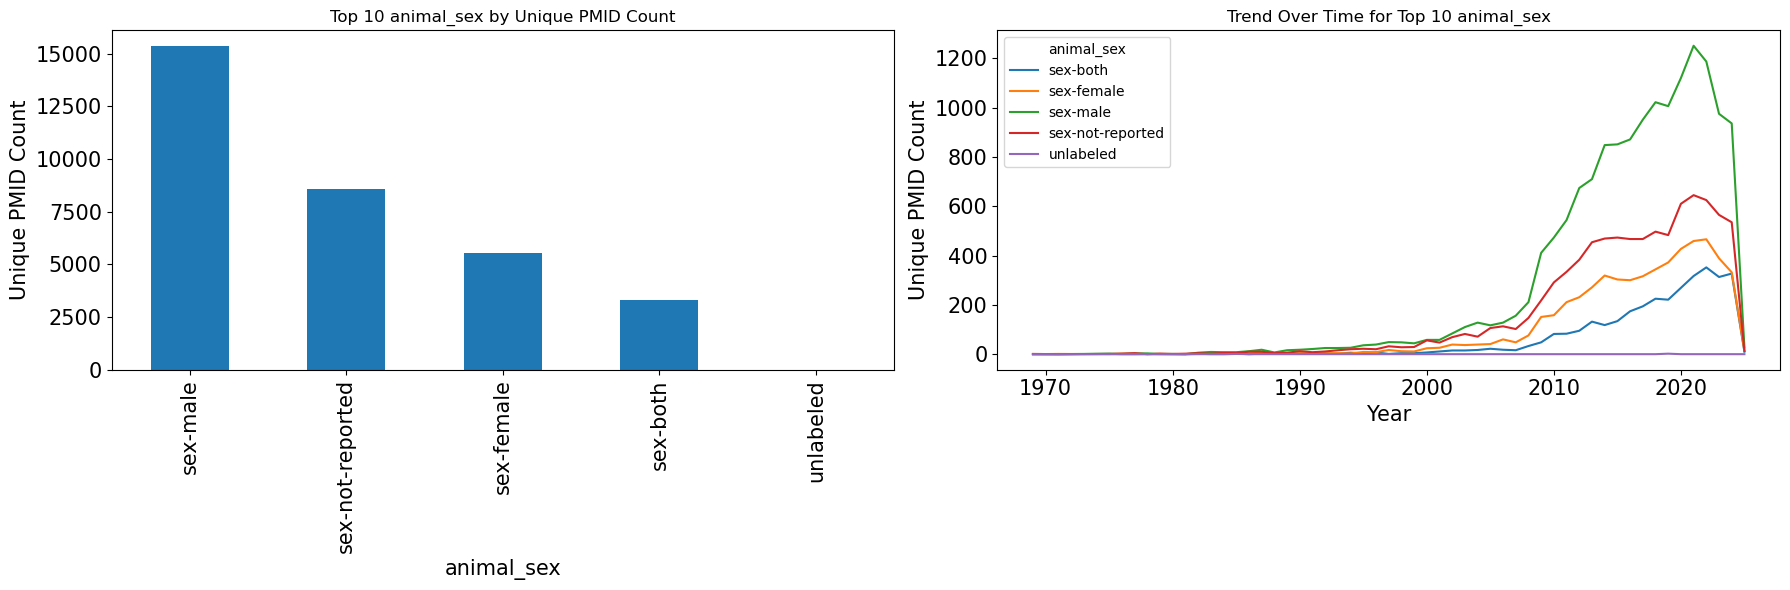

In [60]:
plot_counts_and_trends(preclinical_df, "animal_sex", max_label_length=16)

In [37]:
conditions_col_to_use = "disease"
drugs_col_to_use = "drug"

preclinical_df[conditions_col_to_use] = preclinical_df[conditions_col_to_use].str.split("|")
preclinical_df = preclinical_df.explode(conditions_col_to_use, ignore_index=True)

preclinical_df[drugs_col_to_use] = preclinical_df[drugs_col_to_use].str.split("|")
preclinical_df = preclinical_df.explode(drugs_col_to_use, ignore_index=True)

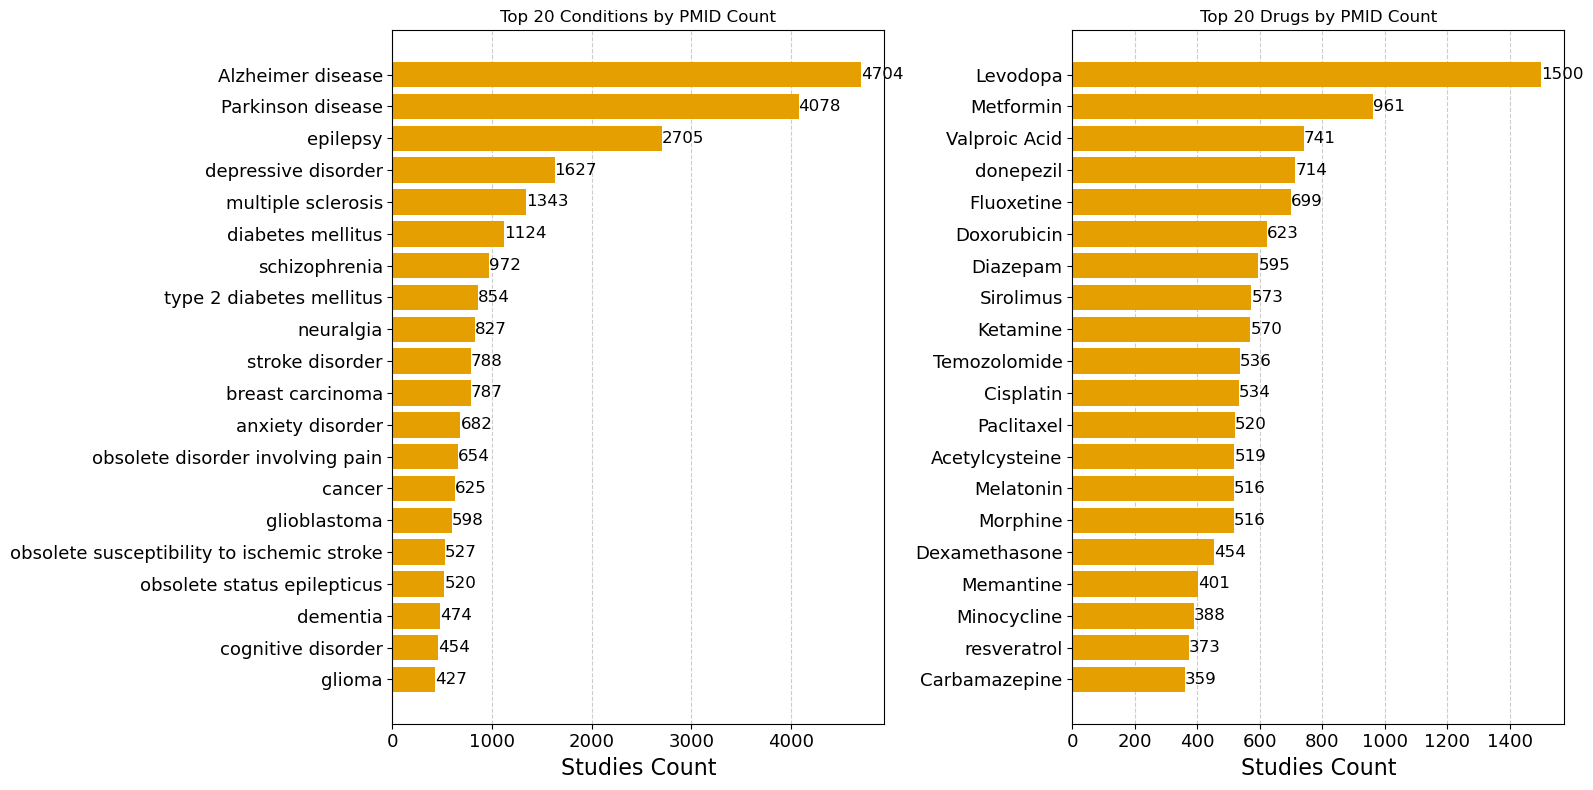

In [39]:
plot_top_entities_side_by_side(preclinical_df, 'PMID', conditions_col_to_use, drugs_col_to_use, save=False)

In [41]:
preclinical_df.shape

(195736, 24)

In [43]:
preclinical_df[['PMID','drug','disease']].head()

,PMID,drug,disease
0,31733940,Minocycline,cognitive disorder
1,31734290,perampanel,glioma-associated seizures
2,31734290,perampanel,glioma-associated seizures
3,31734290,perampanel,glioma-associated seizures
4,31734290,perampanel,glioma-associated epilepsy
